# 02 — Preprocesamiento y Limpieza + Ingeniería de Características
**Proyecto:** Placas-Deteccion-Robo
**Puntos del PDF:** 3) Preprocesamiento y Limpieza, 4) Ingeniería de Características

Continúa desde `01_eda.ipynb` (mismo entorno de Colab, mismo `data/raw`).

Pasos:
1. Convertir anotaciones Pascal VOC (XML) → formato YOLO (`.txt` normalizado)
2. Descartar imágenes huérfanas / anotaciones corruptas detectadas en el EDA
3. Split train/val/test (70/20/10)
4. Definir augmentaciones (documentadas, YOLO las aplica en el entrenamiento)
5. `data.yaml` para Ultralytics


In [1]:
import os

# Si corre en Colab: monta Google Drive y se para en la carpeta ml-service
# ahi adentro, para que 01/02/03 compartan data/ y model/ entre runtimes
# distintos. Si corre local (VS Code), solo ajusta el cwd a ml-service/.
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')
    # Ajusta esta ruta si pusiste la carpeta en otro lugar de tu Drive
    DRIVE_PATH = '/content/drive/MyDrive/Placas-Deteccion-Robo/ml-service'
    os.chdir(DRIVE_PATH)
elif os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

print('Working directory:', os.getcwd())


Working directory: c:\KAPA-2025\VIco\Placas-Deteccion-Robo\ml-service


### 2.1 Conversión de anotaciones VOC (XML) a formato YOLO

Formato YOLO por línea: `clase x_centro y_centro ancho alto` (todo normalizado 0–1). Como hay una sola clase, `clase = 0` (`placa`).

In [2]:
import os
import xml.etree.ElementTree as ET

RAW_DIR = 'data/raw'
IMAGES_DIR = os.path.join(RAW_DIR, 'images')
ANNOT_DIR = os.path.join(RAW_DIR, 'annotations')
YOLO_LABELS_DIR = os.path.join(RAW_DIR, 'labels_yolo')
os.makedirs(YOLO_LABELS_DIR, exist_ok=True)

CLASS_ID = 0  # única clase: "placa"

def voc_to_yolo(xml_path, out_dir):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    filename = root.find('filename').text
    size = root.find('size')
    W, H = int(size.find('width').text), int(size.find('height').text)

    lines = []
    for obj in root.findall('object'):
        b = obj.find('bndbox')
        xmin, ymin = int(b.find('xmin').text), int(b.find('ymin').text)
        xmax, ymax = int(b.find('xmax').text), int(b.find('ymax').text)

        x_center = ((xmin + xmax) / 2) / W
        y_center = ((ymin + ymax) / 2) / H
        w = (xmax - xmin) / W
        h = (ymax - ymin) / H
        lines.append(f'{CLASS_ID} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}')

    txt_name = os.path.splitext(filename)[0] + '.txt'
    with open(os.path.join(out_dir, txt_name), 'w') as f:
        f.write('\n'.join(lines))
    return filename

converted = []
skipped = []
for ann in sorted(os.listdir(ANNOT_DIR)):
    try:
        fname = voc_to_yolo(os.path.join(ANNOT_DIR, ann), YOLO_LABELS_DIR)
        converted.append(fname)
    except Exception as e:
        skipped.append((ann, str(e)))

print(f'Convertidas: {len(converted)} | Con error/omitidas: {len(skipped)}')
if skipped:
    print(skipped[:5])


Convertidas: 433 | Con error/omitidas: 0


### 2.2 Descartar imágenes sin anotación válida (limpieza)

In [3]:
import os

all_images = set(os.listdir(IMAGES_DIR))
valid_images = set(converted)  # nombres de imagen con .txt generado
orphan_images = all_images - valid_images

print(f'Imágenes totales: {len(all_images)}')
print(f'Imágenes válidas (con anotación): {len(valid_images)}')
print(f'Imágenes huérfanas descartadas: {len(orphan_images)}')


Imágenes totales: 433
Imágenes válidas (con anotación): 433
Imágenes huérfanas descartadas: 0


### 2.3 Split train/val/test (70/20/10)

In [4]:
import random
import shutil

random.seed(42)
images_list = sorted(valid_images)
random.shuffle(images_list)

n = len(images_list)
n_train = int(n * 0.70)
n_val = int(n * 0.20)

split = {
    'train': images_list[:n_train],
    'val': images_list[n_train:n_train + n_val],
    'test': images_list[n_train + n_val:],
}

PROCESSED_DIR = 'data/processed'
for subset in split:
    os.makedirs(f'{PROCESSED_DIR}/images/{subset}', exist_ok=True)
    os.makedirs(f'{PROCESSED_DIR}/labels/{subset}', exist_ok=True)

for subset, files in split.items():
    for fname in files:
        base = os.path.splitext(fname)[0]
        shutil.copy(os.path.join(IMAGES_DIR, fname), f'{PROCESSED_DIR}/images/{subset}/{fname}')
        shutil.copy(os.path.join(YOLO_LABELS_DIR, base + '.txt'), f'{PROCESSED_DIR}/labels/{subset}/{base}.txt')
    print(f'{subset}: {len(files)} imágenes')


train: 303 imágenes
val: 86 imágenes
test: 44 imágenes


### 2.4 Ingeniería de características (aplicado a visión)

En un dataset tabular esto sería selección/transformación de columnas. Acá el equivalente es:

- **Tamaño de entrada del modelo:** 640x640 (estándar YOLOv8, buen balance velocidad/precisión para placas que no son objetos gigantes en la imagen).
- **Augmentaciones a usar durante el entrenamiento** (las aplica Ultralytics automáticamente vía `data.yaml` / hyperparámetros, no hace falta generarlas a mano):
  - `fliplr=0.5` (flip horizontal, las placas se ven igual espejadas en cuanto a posición del objeto)
  - `hsv_h/hsv_s/hsv_v` (variación de brillo/color, simula distintas condiciones de luz — relevante porque las placas se leen en exteriores)
  - **No usar** flip vertical (`flipud=0`): una placa invertida verticalmente no tiene sentido real.
- **Preprocesamiento del recorte antes del OCR** (se aplica en `ml-service/app/main.py`, no en el notebook de entrenamiento):
  - Conversión a escala de grises
  - Umbralización/threshold adaptativo para mejorar contraste del texto
  - Corrección de inclinación (deskew) simple si el bbox viene rotado

Justificación breve: estas transformaciones no agregan columnas nuevas como en tabular, pero cumplen el mismo rol — quedarse con la información relevante (forma/textura de los caracteres) y descartar ruido (iluminación, fondo) antes de que el modelo/OCR reciba la imagen.


### 2.5 `data.yaml` para Ultralytics

In [5]:
data_yaml = f'''
path: {os.path.abspath(PROCESSED_DIR)}
train: images/train
val: images/val
test: images/test

names:
  0: placa
'''

with open(f'{PROCESSED_DIR}/data.yaml', 'w') as f:
    f.write(data_yaml)

print(data_yaml)



path: c:\KAPA-2025\VIco\Placas-Deteccion-Robo\ml-service\data\processed
train: images/train
val: images/val
test: images/test

names:
  0: placa



### 2.6 Verificación visual rápida (labels YOLO correctamente alineados)

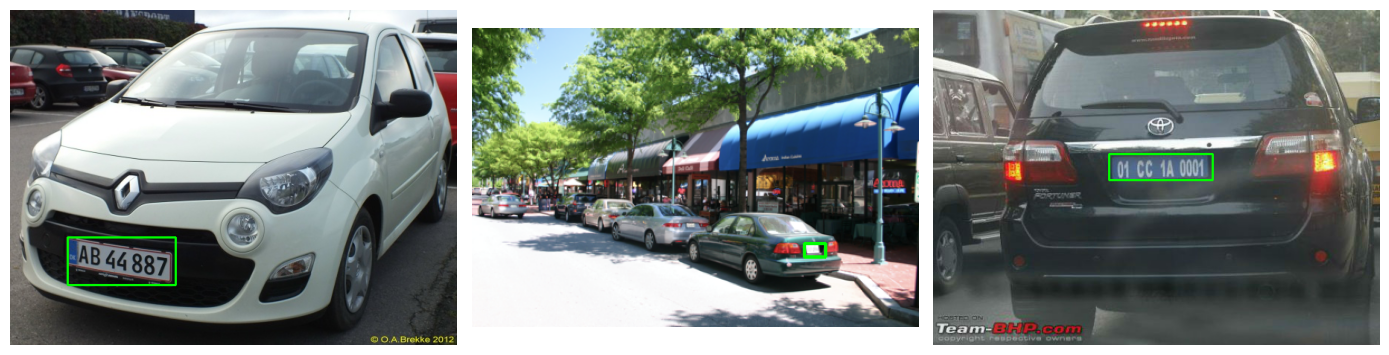

In [6]:
import cv2
import matplotlib.pyplot as plt

def draw_yolo_label(img_path, label_path, ax):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    H, W = img.shape[:2]
    with open(label_path) as f:
        for line in f:
            cls, xc, yc, w, h = map(float, line.split())
            xc, yc, w, h = xc * W, yc * H, w * W, h * H
            x1, y1 = int(xc - w / 2), int(yc - h / 2)
            x2, y2 = int(xc + w / 2), int(yc + h / 2)
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
    ax.imshow(img)
    ax.axis('off')

sample = split['train'][:3]
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for fname, ax in zip(sample, axes):
    base = os.path.splitext(fname)[0]
    draw_yolo_label(
        f'{PROCESSED_DIR}/images/train/{fname}',
        f'{PROCESSED_DIR}/labels/train/{base}.txt',
        ax
    )
plt.tight_layout()
plt.show()
